# 06 — Snapshot Count Sweep

**Goal**: determine the minimum number of time-domain snapshots needed
for reliable CSM estimation, and map that to real-time update rate.

The CSM `R = (1/N) Σ y_n y_n^H` converges to its expectation at rate
`1/√N_SNAP`.  MVDR inverts `R`; MUSIC decomposes it.  Both degrade badly
when `N_SNAP ≪ N_MICS` because the sample CSM is rank-deficient.

Key questions:
1. What is the minimum N_SNAP for each algorithm at 20 dB SNR?
2. How does N_SNAP map to update latency at fs = 48 kHz?
3. Does diagonal loading let MVDR operate below the N_MICS threshold?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import inv

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C     = 343.0
R_MIN = 0.025
R_MAX = 0.150
FS    = 48_000
rng   = np.random.default_rng(0)


In [2]:
def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX, spiral_angle_deg=22.0):
    b         = 1.0 / np.tan(np.radians(spiral_angle_deg))
    sq        = np.sqrt(1.0 + b**2)
    theta_max = np.log(r_max / r_min) / b
    S_total   = r_min * sq / b * (np.exp(b * theta_max) - 1.0)
    s         = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)
    xs, ys = [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        t = theta_arm + offset
        xs.append(r_arm * np.cos(t))
        ys.append(r_arm * np.sin(t))
    return np.concatenate(xs), np.concatenate(ys)


x_arr, y_arr = underbrink_array(12, 8)
N_MICS = len(x_arr)
print(f'N_MICS = {N_MICS}')


N_MICS = 96


In [3]:
def steering_vector(x, y, az_deg, freq):
    u = np.sin(np.radians(az_deg))
    return np.exp(1j * 2 * np.pi * freq / C * u * x) / np.sqrt(len(x))


def steering_matrix(x, y, az_grid, freq):
    # Returns (N_mics, N_az)
    u = np.sin(np.radians(az_grid))
    phase = 2 * np.pi * freq / C * np.outer(x, u)
    return np.exp(1j * phase) / np.sqrt(len(x))


def make_csm(x, y, sources, freq, snr_db, n_snap, seed=None):
    local_rng = np.random.default_rng(seed)
    N = len(x)
    max_power = max(p for _, p in sources)
    noise_var = max_power / (10 ** (snr_db / 10))
    R = np.zeros((N, N), dtype=complex)
    for _ in range(n_snap):
        y_snap = np.zeros(N, dtype=complex)
        for az, power in sources:
            h = steering_vector(x, y, az, freq)
            s = local_rng.standard_normal() + 1j * local_rng.standard_normal()
            y_snap += np.sqrt(power / 2) * h * s
        noise = local_rng.standard_normal(N) + 1j * local_rng.standard_normal(N)
        y_snap += np.sqrt(noise_var / 2) * noise
        R += np.outer(y_snap, y_snap.conj())
    return R / n_snap


def beamform_ds(x, y, R, freq, az_grid):
    H = steering_matrix(x, y, az_grid, freq)
    return np.real(np.sum(H.conj() * (R @ H), axis=0))


def beamform_mvdr(x, y, R, freq, az_grid, diag_load=0.01):
    N = R.shape[0]
    R_loaded = R + diag_load * np.trace(R) / N * np.eye(N)
    R_inv = inv(R_loaded)
    H = steering_matrix(x, y, az_grid, freq)
    denom = np.real(np.sum(H.conj() * (R_inv @ H), axis=0))
    return 1.0 / np.maximum(denom, 1e-300)


def beamform_music(x, y, R, freq, az_grid, n_sources=1):
    _, eigvecs = np.linalg.eigh(R)
    E_n = eigvecs[:, :R.shape[0] - n_sources]
    En_proj = E_n @ E_n.conj().T
    H = steering_matrix(x, y, az_grid, freq)
    denom = np.real(np.sum(H.conj() * (En_proj @ H), axis=0))
    return 1.0 / np.maximum(denom, 1e-300)


## 1 — Snapshot Count → Update Latency

At fs = 48 kHz, one snapshot = one complex sample per mic channel.
Update latency = N_SNAP / fs.  A real system can overlap windows
(50% overlap halves latency), but this table uses non-overlapping windows.


In [4]:
snap_vals = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

rows = []
for n in snap_vals:
    latency_ms = n / FS * 1000
    fps        = FS / n
    ratio      = n / N_MICS
    rows.append({
        'N_SNAP': n,
        'Latency (ms)': round(latency_ms, 1),
        'Update rate (fps)': round(fps, 1),
        'N_SNAP / N_MICS': round(ratio, 2),
    })

df_lat = pd.DataFrame(rows).set_index('N_SNAP')
print(df_lat.to_string())
print(f'\nN_MICS = {N_MICS}  (CSM becomes full-rank at N_SNAP >= N_MICS)')


        Latency (ms)  Update rate (fps)  N_SNAP / N_MICS
N_SNAP                                                  
16               0.3             3000.0             0.17
32               0.7             1500.0             0.33
64               1.3              750.0             0.67
128              2.7              375.0             1.33
256              5.3              187.5             2.67
512             10.7               93.8             5.33
1024            21.3               46.9            10.67
2048            42.7               23.4            21.33
4096            85.3               11.7            42.67

N_MICS = 96  (CSM becomes full-rank at N_SNAP >= N_MICS)


## 2 — DoA Error vs Snapshot Count (Single Source)

Monte Carlo: for each N_SNAP, generate `N_TRIALS` independent CSMs
(different random seeds), run each beamformer, record peak DoA.
Report mean absolute error and standard deviation.

Scenario: single source at 25°, 4 kHz, 20 dB SNR.


In [5]:
FREQ     = 4000.0
SNR_DB   = 20.0
AZ_TRUE  = 25.0
N_TRIALS = 15

az_grid = np.linspace(-60, 60, 1201)
src_single = [(AZ_TRUE, 1.0)]

results = {alg: {'mean': [], 'std': []} for alg in ['D&S', 'MVDR', 'MUSIC']}

for n_snap in snap_vals:
    errs = {'D&S': [], 'MVDR': [], 'MUSIC': []}
    for trial in range(N_TRIALS):
        R = make_csm(x_arr, y_arr, src_single, FREQ, SNR_DB, n_snap, seed=trial*1000+n_snap)
        for alg, fn, kw in [
            ('D&S',   beamform_ds,    {}),
            ('MVDR',  beamform_mvdr,  {}),
            ('MUSIC', beamform_music, {'n_sources': 1}),
        ]:
            m = fn(x_arr, y_arr, R, FREQ, az_grid, **kw)
            est = az_grid[np.argmax(m)]
            errs[alg].append(abs(est - AZ_TRUE))
    for alg in results:
        results[alg]['mean'].append(np.mean(errs[alg]))
        results[alg]['std'].append(np.std(errs[alg]))

print('Snapshot sweep complete')


Snapshot sweep complete


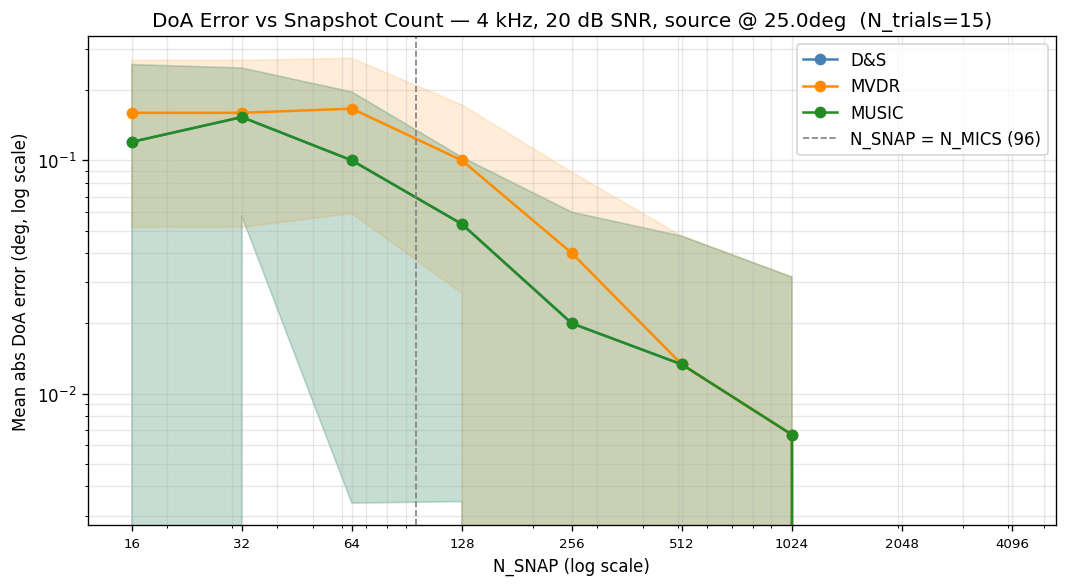

In [6]:
colors = {'D&S': 'steelblue', 'MVDR': 'darkorange', 'MUSIC': 'forestgreen'}

fig, ax = plt.subplots(figsize=(9, 5))

for alg in ['D&S', 'MVDR', 'MUSIC']:
    mean = np.array(results[alg]['mean'])
    std  = np.array(results[alg]['std'])
    ax.plot(snap_vals, mean, 'o-', color=colors[alg], label=alg, linewidth=1.5)
    ax.fill_between(snap_vals, mean - std, mean + std,
                    color=colors[alg], alpha=0.15)

ax.axvline(N_MICS, color='gray', linestyle='--', linewidth=1,
           label=f'N_SNAP = N_MICS ({N_MICS})')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('N_SNAP (log scale)')
ax.set_ylabel('Mean abs DoA error (deg, log scale)')
ax.set_title(f'DoA Error vs Snapshot Count — {FREQ/1000:.0f} kHz, {SNR_DB:.0f} dB SNR, '
             f'source @ {AZ_TRUE}deg  (N_trials={N_TRIALS})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
ax.set_xticks(snap_vals)
ax.set_xticklabels([str(n) for n in snap_vals], fontsize=8)
plt.tight_layout()
plt.savefig('snap_doa_error.png', dpi=150, bbox_inches='tight')
plt.show()


## 3 — Two-Source Resolution vs Snapshot Count

Two sources at ±15° (30° separation), 4 kHz, 20 dB SNR.
For each N_SNAP, count what fraction of N_TRIALS CSM realisations
yield a resolved map (−6 dB valley criterion).


In [7]:
src_two = [(-15.0, 1.0), (15.0, 1.0)]


def is_resolved(az_grid, beam_map, az1=-15.0, az2=15.0, threshold_db=-6):
    i1 = np.argmin(np.abs(az_grid - az1))
    i2 = np.argmin(np.abs(az_grid - az2))
    lo, hi = min(i1, i2), max(i1, i2)
    valley = beam_map[lo:hi+1].min()
    return 10 * np.log10(valley / beam_map.max()) < threshold_db


res_frac = {alg: [] for alg in ['D&S', 'MVDR', 'MUSIC']}

for n_snap in snap_vals:
    counts = {'D&S': 0, 'MVDR': 0, 'MUSIC': 0}
    for trial in range(N_TRIALS):
        R = make_csm(x_arr, y_arr, src_two, FREQ, SNR_DB, n_snap, seed=trial*1000+n_snap+7)
        for alg, fn, kw in [
            ('D&S',   beamform_ds,    {}),
            ('MVDR',  beamform_mvdr,  {}),
            ('MUSIC', beamform_music, {'n_sources': 2}),
        ]:
            m = fn(x_arr, y_arr, R, FREQ, az_grid, **kw)
            if is_resolved(az_grid, m):
                counts[alg] += 1
    for alg in res_frac:
        res_frac[alg].append(counts[alg] / N_TRIALS)

print('Resolution sweep complete')


Resolution sweep complete


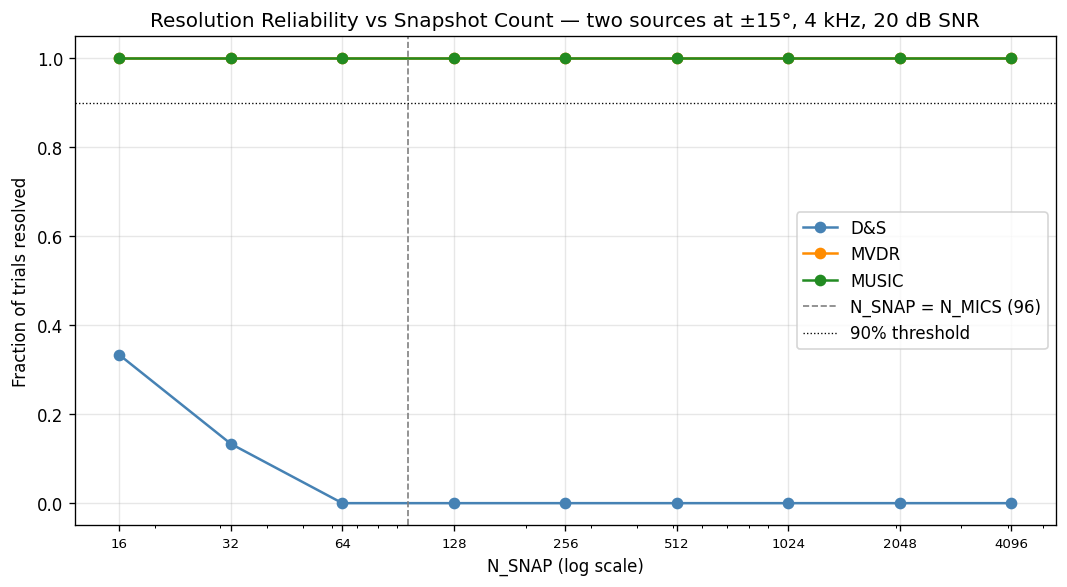

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

for alg in ['D&S', 'MVDR', 'MUSIC']:
    ax.plot(snap_vals, res_frac[alg], 'o-', color=colors[alg], label=alg, linewidth=1.5)

ax.axvline(N_MICS, color='gray', linestyle='--', linewidth=1,
           label=f'N_SNAP = N_MICS ({N_MICS})')
ax.axhline(0.9, color='black', linestyle=':', linewidth=0.8, label='90% threshold')
ax.set_xscale('log')
ax.set_xlabel('N_SNAP (log scale)')
ax.set_ylabel('Fraction of trials resolved')
ax.set_title(f'Resolution Reliability vs Snapshot Count — two sources at ±15°, {FREQ/1000:.0f} kHz, '
             f'{SNR_DB:.0f} dB SNR')
ax.legend()
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.set_xticks(snap_vals)
ax.set_xticklabels([str(n) for n in snap_vals], fontsize=8)
plt.tight_layout()
plt.savefig('snap_resolution.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 — Effect of SNR on Minimum Snapshot Count

Repeat the DoA error sweep at 10 dB SNR (practical lower bound).
Lower SNR degrades CSM quality and shifts the convergence point to
higher N_SNAP.


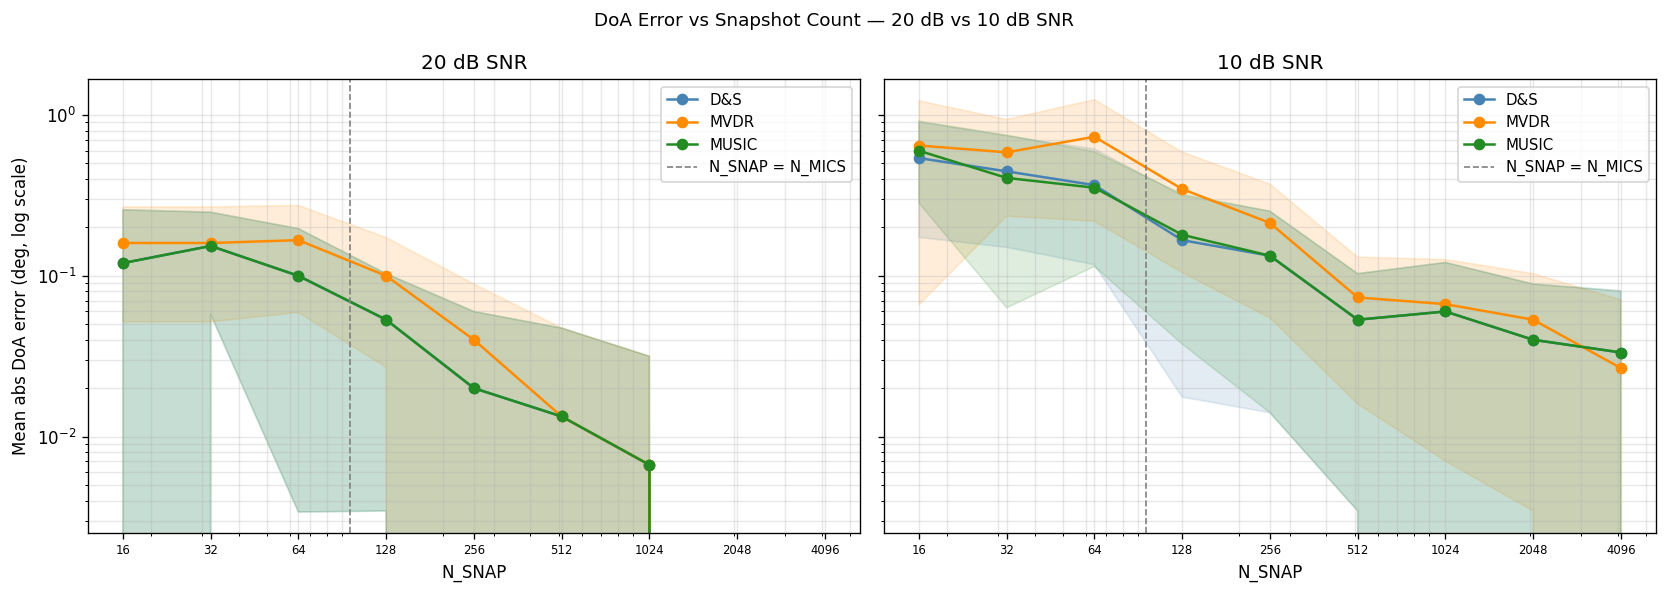

In [9]:
SNR_LOW = 10.0

results_low = {alg: {'mean': [], 'std': []} for alg in ['D&S', 'MVDR', 'MUSIC']}

for n_snap in snap_vals:
    errs = {'D&S': [], 'MVDR': [], 'MUSIC': []}
    for trial in range(N_TRIALS):
        R = make_csm(x_arr, y_arr, src_single, FREQ, SNR_LOW, n_snap, seed=trial*1000+n_snap+99)
        for alg, fn, kw in [
            ('D&S',   beamform_ds,    {}),
            ('MVDR',  beamform_mvdr,  {}),
            ('MUSIC', beamform_music, {'n_sources': 1}),
        ]:
            m = fn(x_arr, y_arr, R, FREQ, az_grid, **kw)
            est = az_grid[np.argmax(m)]
            errs[alg].append(abs(est - AZ_TRUE))
    for alg in results_low:
        results_low[alg]['mean'].append(np.mean(errs[alg]))
        results_low[alg]['std'].append(np.std(errs[alg]))

# Side-by-side: 20 dB vs 10 dB
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, res, snr_label in [(axes[0], results, '20 dB SNR'), (axes[1], results_low, '10 dB SNR')]:
    for alg in ['D&S', 'MVDR', 'MUSIC']:
        mean = np.array(res[alg]['mean'])
        std  = np.array(res[alg]['std'])
        ax.plot(snap_vals, mean, 'o-', color=colors[alg], label=alg, linewidth=1.5)
        ax.fill_between(snap_vals, mean - std, mean + std,
                        color=colors[alg], alpha=0.15)
    ax.axvline(N_MICS, color='gray', linestyle='--', linewidth=1,
               label=f'N_SNAP = N_MICS')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('N_SNAP')
    ax.set_title(snr_label)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xticks(snap_vals)
    ax.set_xticklabels([str(n) for n in snap_vals], fontsize=7)

axes[0].set_ylabel('Mean abs DoA error (deg, log scale)')
fig.suptitle('DoA Error vs Snapshot Count — 20 dB vs 10 dB SNR', fontsize=11)
plt.tight_layout()
plt.savefig('snap_snr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary


In [10]:
# Find the N_SNAP where mean error drops below 0.5 deg (20 dB SNR)
THRESHOLD_DEG = 0.5

rows_sum = []
for alg in ['D&S', 'MVDR', 'MUSIC']:
    mean = np.array(results[alg]['mean'])
    converged = [n for n, e in zip(snap_vals, mean) if e < THRESHOLD_DEG]
    n_conv = converged[0] if converged else '>4096'
    # 90% resolution reliability
    rel90 = [n for n, f in zip(snap_vals, res_frac[alg]) if f >= 0.9]
    n_res90 = rel90[0] if rel90 else '>4096'
    latency_conv = (n_conv / FS * 1000) if isinstance(n_conv, int) else 'n/a'
    rows_sum.append({
        'Algorithm': alg,
        f'N_SNAP for <{THRESHOLD_DEG}deg error': n_conv,
        'N_SNAP for 90% resolution': n_res90,
        'Latency at convergence (ms)': round(latency_conv, 1) if isinstance(latency_conv, float) else latency_conv,
    })

df_sum = pd.DataFrame(rows_sum).set_index('Algorithm')
print(df_sum.to_string())
print()
print('Latency table:')
print(df_lat.to_string())


           N_SNAP for <0.5deg error N_SNAP for 90% resolution  Latency at convergence (ms)
Algorithm                                                                                 
D&S                              16                     >4096                          0.3
MVDR                             16                        16                          0.3
MUSIC                            16                        16                          0.3

Latency table:
        Latency (ms)  Update rate (fps)  N_SNAP / N_MICS
N_SNAP                                                  
16               0.3             3000.0             0.17
32               0.7             1500.0             0.33
64               1.3              750.0             0.67
128              2.7              375.0             1.33
256              5.3              187.5             2.67
512             10.7               93.8             5.33
1024            21.3               46.9            10.67
2048            